uv venv# Borrower Segmentation Analysis

Compares **Thin File** vs **Traditional** borrowers: population split, default rates, and feature differences.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/borrower_features.csv')
df.head()

,borrower_id,age,location,employment_type,borrower_type,credit_score,traditional_payment_history_pct,credit_inquiries,utility_on_time_pct,rent_avg_days_late,...,job_tenure_months,monthly_income,income_fluctuation_pct,existing_debt,is_default,savings_ratio,debt_to_income_ratio,income_stability_score,is_gig_worker,payment_reliability_score
0,B_000000,56,Suburban,Unemployed,Thin File,NaN,NaN,NaN,0.589528,0.090301,...,0.005814,4256.85,45.83,1102.83,1,0.000266,0.002231,0.083217,0,0.767674
1,B_000001,69,Urban,Salaried,Traditional,660.345321,70.440420,1.0,0.615900,0.086612,...,0.113372,2569.61,6.21,40.87,0,0.001289,0.000124,0.875775,0,0.781966
2,B_000002,46,Urban,Self-Employed,Traditional,781.066181,71.018850,3.0,0.498373,0.121845,...,0.017442,3919.33,9.49,650.99,0,0.000138,0.001425,0.810162,0,0.712633
3,B_000003,32,Rural,Salaried,Traditional,620.043362,84.113594,0.0,0.723167,0.422473,...,0.026163,6463.19,9.97,1458.34,1,0.000367,0.001941,0.800560,0,0.734842
4,B_000004,60,Urban,Self-Employed,Traditional,726.648661,73.627261,0.0,0.845216,0.062977,...,0.264535,17874.37,32.56,1180.48,0,0.000379,0.000558,0.348670,0,0.870382


## 1. Population Split

In [2]:
total_borrowers = len(df)
thin_files = df[df['borrower_type'] == 'Thin File']
traditional = df[df['borrower_type'] == 'Traditional']

thin_file_pct = (len(thin_files) / total_borrowers) * 100

print(f"Total Borrowers: {total_borrowers}")
print(f"Thin File Borrowers: {len(thin_files)} ({thin_file_pct:.2f}%)")
print(f"Traditional Borrowers: {len(traditional)} ({100 - thin_file_pct:.2f}%)")

Total Borrowers: 10000
Thin File Borrowers: 3142 (31.42%)
Traditional Borrowers: 6858 (68.58%)


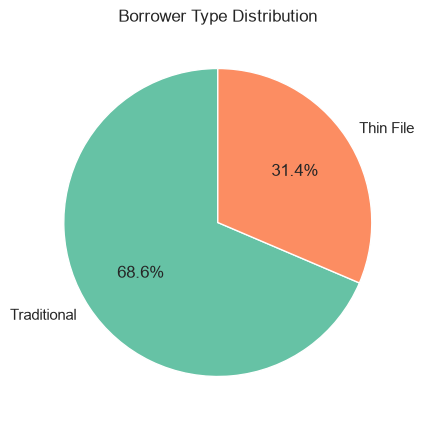

In [3]:
counts = df['borrower_type'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
       colors=sns.color_palette('Set2'))
ax.set_title('Borrower Type Distribution')
plt.show()

## 2. Default Rates

In [4]:
overall_default = df['is_default'].mean() * 100
thin_default = thin_files['is_default'].mean() * 100
trad_default = traditional['is_default'].mean() * 100

default_rates = pd.Series({
    'Overall': overall_default,
    'Thin File': thin_default,
    'Traditional': trad_default
})
print(default_rates.round(2))

Overall        26.94
Thin File      32.37
Traditional    24.45
dtype: float64


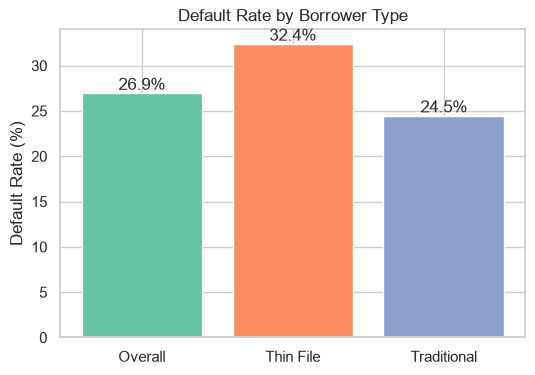

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(default_rates.index, default_rates.values, color=sns.color_palette('Set2'))
ax.bar_label(bars, fmt='%.1f%%')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Borrower Type')
plt.show()

## 3. Feature Comparison

In [6]:
features_to_compare = [
    'age', 'utility_on_time_pct', 'rent_avg_days_late',
    'avg_bank_balance', 'payment_reliability_score', 'income_stability_score'
]

comp_df = df.groupby('borrower_type')[features_to_compare].mean().T
comp_df

borrower_type,Thin File,Traditional
age,39.564290,45.360601
utility_on_time_pct,0.702977,0.703555
rent_avg_days_late,0.086289,0.085607
avg_bank_balance,0.008467,0.008726
payment_reliability_score,0.808967,0.809210
income_stability_score,0.688824,0.757888


/var/folders/1w/wn31x_g14vbd2br3ln9s2nrc0000gn/T/ipykernel_37630/3730846430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='borrower_type', y=feature, ax=ax, palette='Set2')
/var/folders/1w/wn31x_g14vbd2br3ln9s2nrc0000gn/T/ipykernel_37630/3730846430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='borrower_type', y=feature, ax=ax, palette='Set2')
/var/folders/1w/wn31x_g14vbd2br3ln9s2nrc0000gn/T/ipykernel_37630/3730846430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='borrower_type', y=feature, 

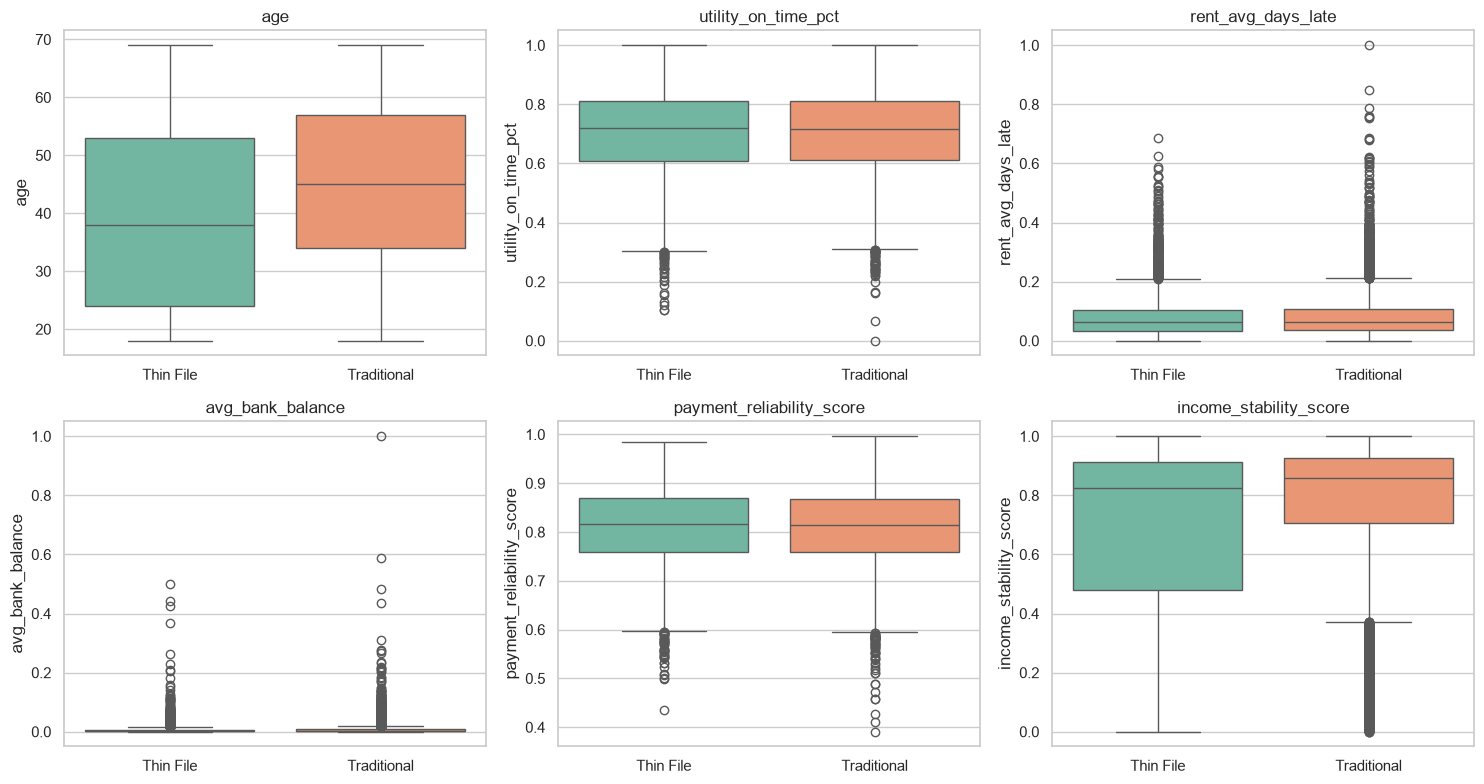

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flat, features_to_compare):
    sns.boxplot(data=df, x='borrower_type', y=feature, ax=ax, palette='Set2')
    ax.set_title(feature)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Save Report

In [8]:
report_output_path = 'segmentation_report.md'

with open(report_output_path, 'w') as f:
    f.write("# Borrower Segmentation Analysis\n\n")
    f.write(f"Total Borrowers: {total_borrowers}\n")
    f.write(f"Thin File Borrowers: {len(thin_files)} ({thin_file_pct:.2f}%)\n")
    f.write(f"Traditional Borrowers: {len(traditional)} ({100 - thin_file_pct:.2f}%)\n\n")
    f.write("## Default Rates\n")
    f.write(f"Overall Default Rate: {overall_default:.2f}%\n")
    f.write(f"Thin File Default Rate: {thin_default:.2f}%\n")
    f.write(f"Traditional Default Rate: {trad_default:.2f}%\n\n")
    f.write("## Feature Comparison (Means)\n")
    f.write(comp_df.to_markdown() + "\n\n")

print(f"Report saved to {report_output_path}")

Report saved to segmentation_report.md
